# Wine Quality Classification — Exploratory Data Analysis

We explore the **UCI Red Wine Quality** dataset to understand the chemistry-vs-quality relationship and decide how to binarize the target.

**Dataset**: 1,599 red-wine samples with 11 physicochemical features and an integer quality score (0–10). For this project we treat **quality >= 7** as "good wine" (binary target).

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("data/winequality-red.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe().round(3)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


In [5]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing values : {df.isnull().sum().sum()}")

Duplicate rows: 240
Missing values : 0


## 4. Quality-Score Distribution

The raw target is an integer score. Most wines cluster at 5–6 — we need to decide a binary cutoff.

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_44160/2709533952.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="viridis", ax=axes[0])


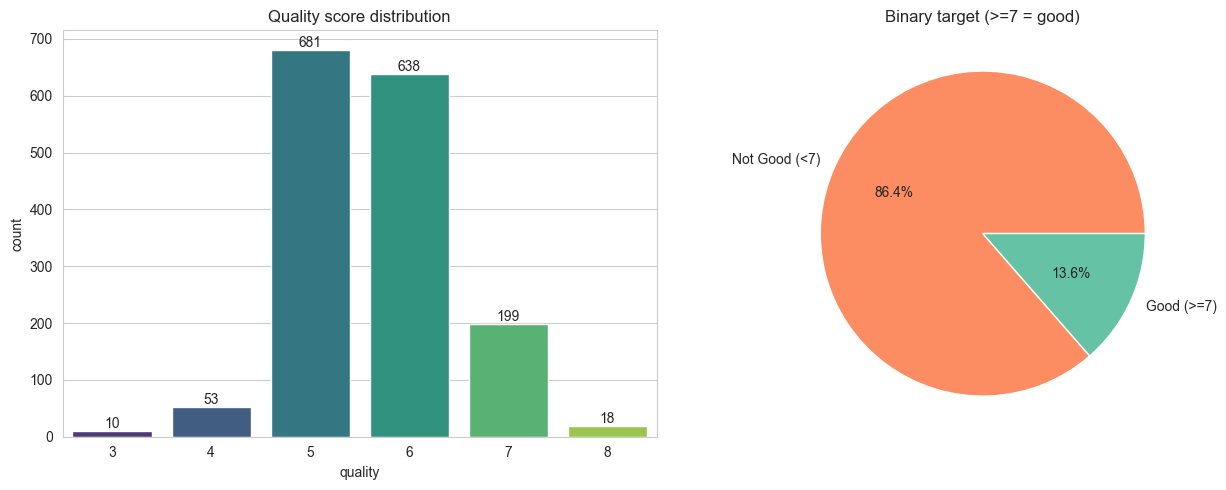

good_quality
0    1382
1     217
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(x="quality", data=df, palette="viridis", ax=axes[0])
axes[0].set_title("Quality score distribution")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha="center", va="bottom", fontsize=10)

# Binary target preview
df["good_quality"] = (df["quality"] >= 7).astype(int)
df["good_quality"].value_counts().plot.pie(
    labels=["Not Good (<7)", "Good (>=7)"], autopct="%1.1f%%",
    colors=["#fc8d62", "#66c2a5"], ax=axes[1])
axes[1].set_ylabel(""); axes[1].set_title("Binary target (>=7 = good)")
plt.tight_layout(); plt.show()
print(df["good_quality"].value_counts())

## 5. Univariate — Feature Distributions

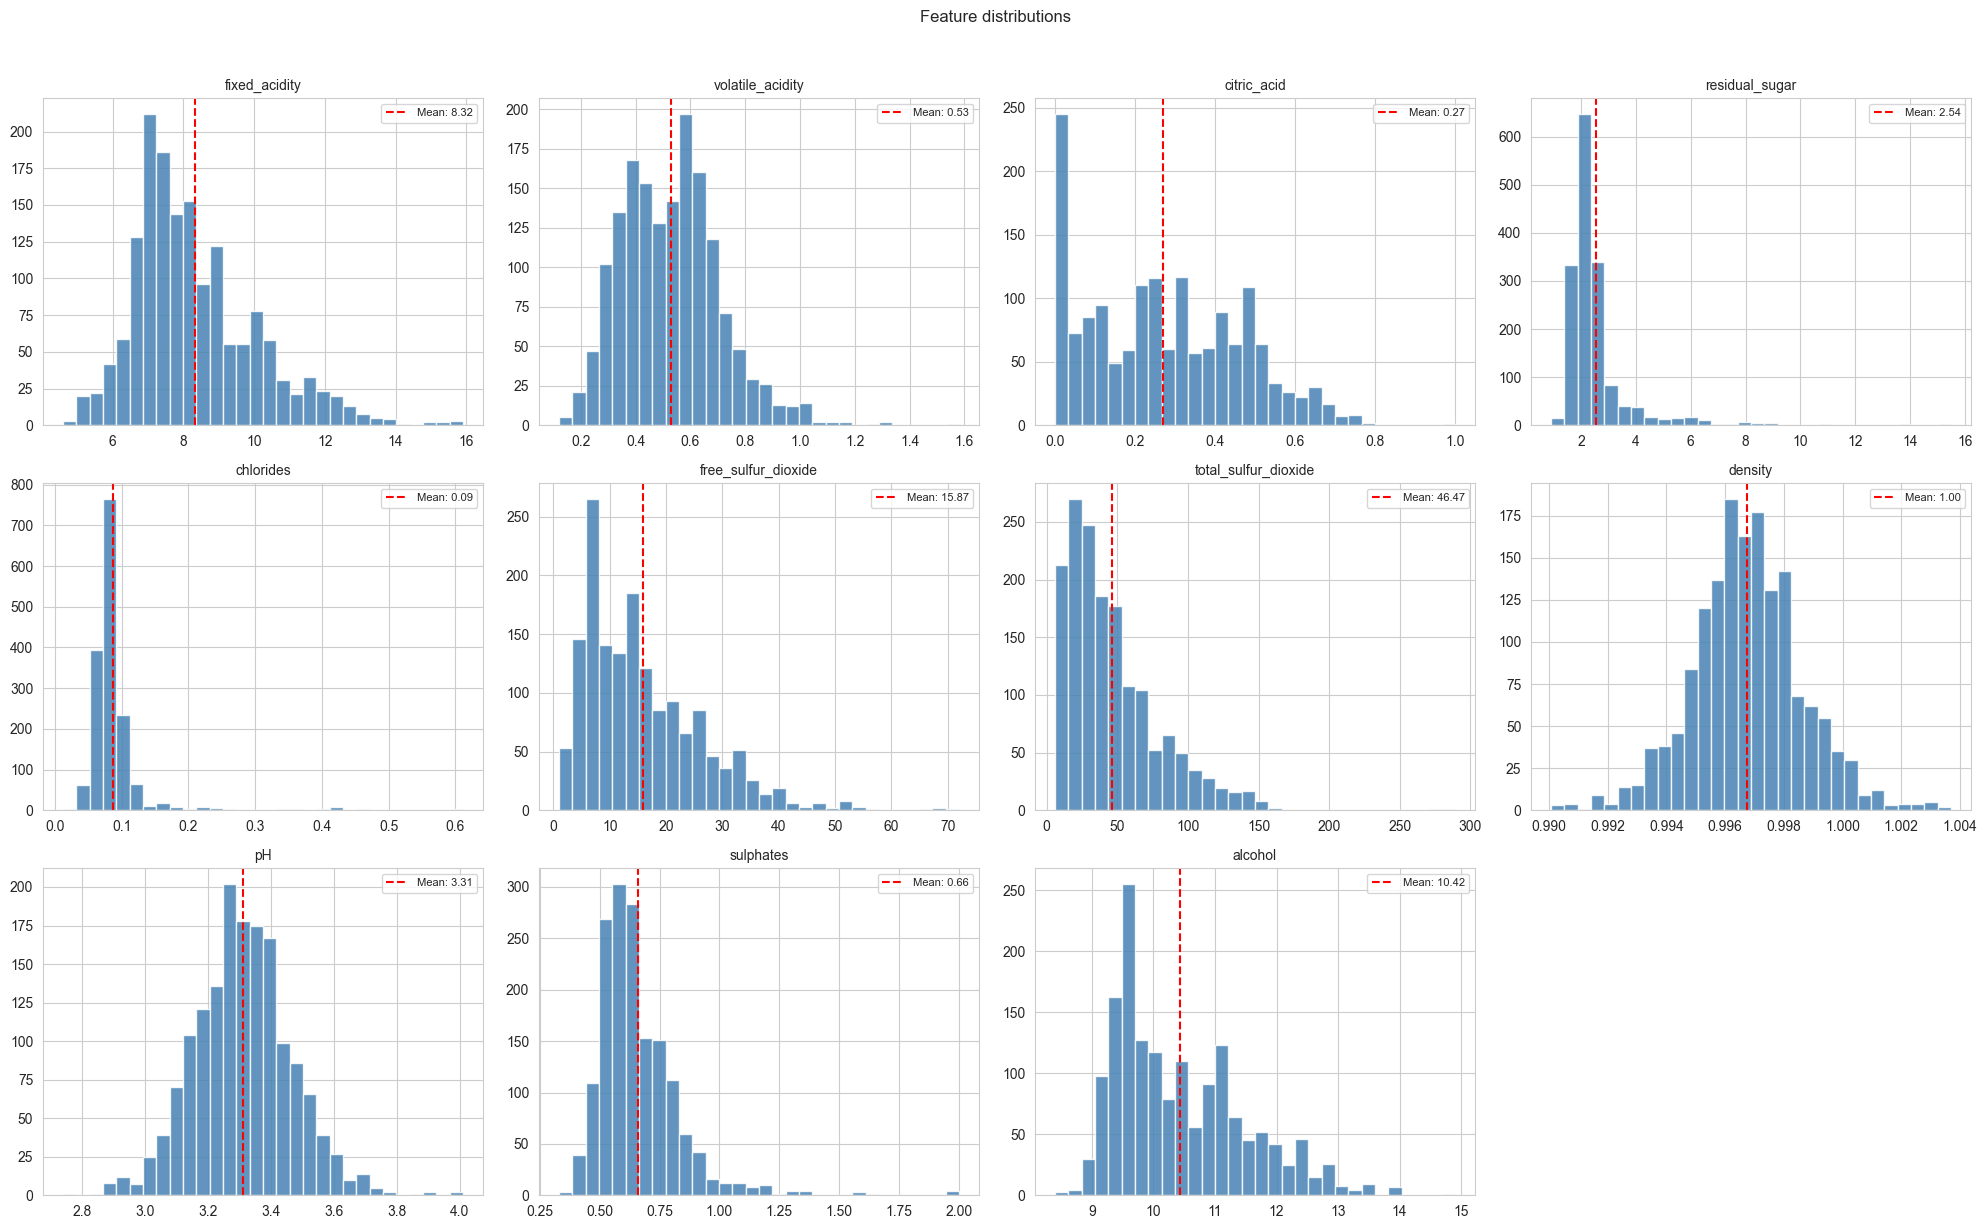

In [7]:
features = [c for c in df.columns if c not in {"quality", "good_quality"}]
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--",
                    label=f"Mean: {df[col].mean():.2f}")
    axes[i].set_title(col, fontsize=10); axes[i].legend(fontsize=8)
for j in range(len(features), len(axes)):
    axes[j].axis("off")
plt.suptitle("Feature distributions", y=1.02); plt.tight_layout(); plt.show()

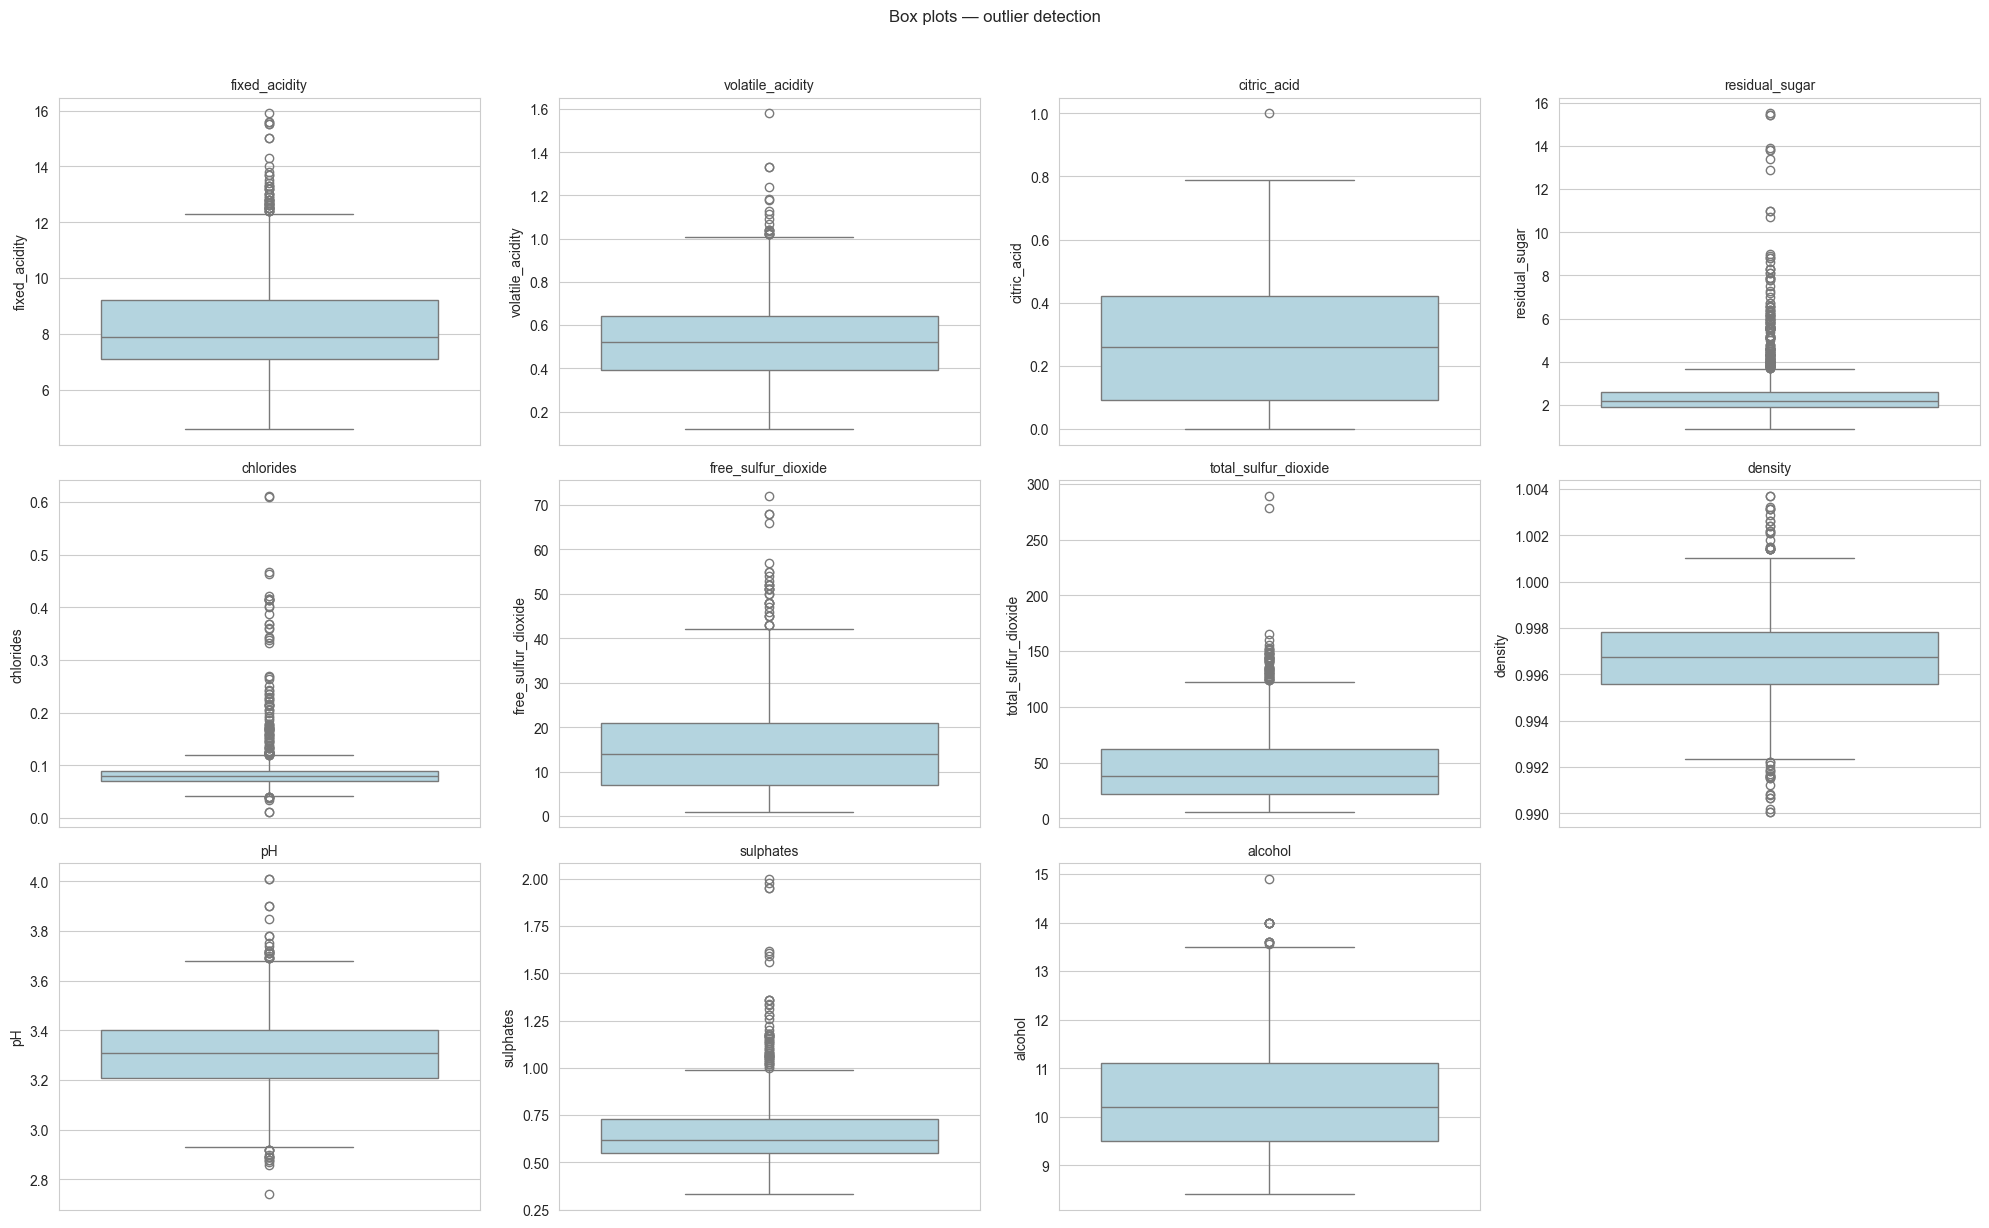

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    axes[i].set_title(col, fontsize=10)
for j in range(len(features), len(axes)):
    axes[j].axis("off")
plt.suptitle("Box plots — outlier detection", y=1.02); plt.tight_layout(); plt.show()

## 6. Bivariate — Features vs Quality (binary)

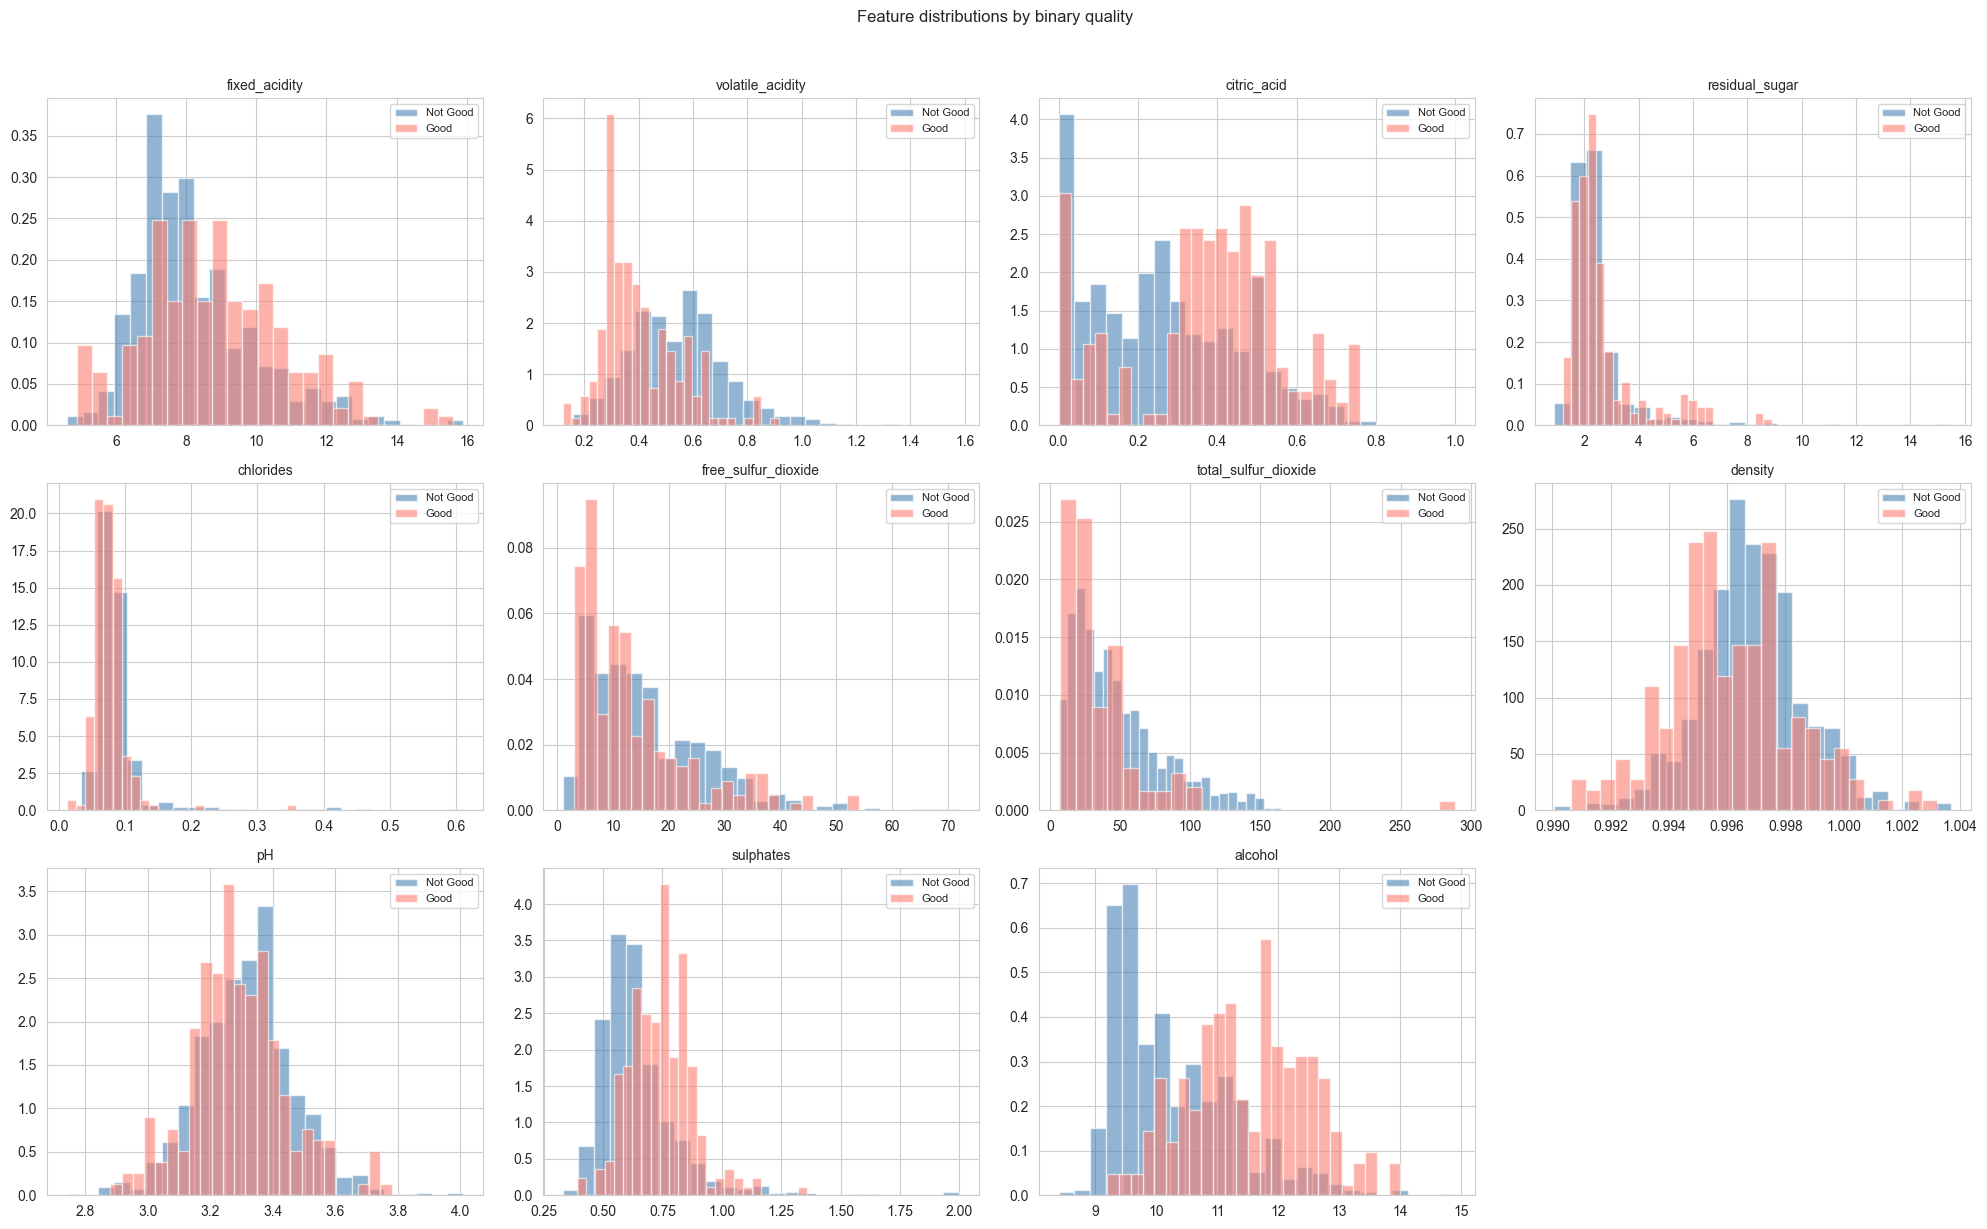

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    for q, color, label in [(0, "steelblue", "Not Good"), (1, "salmon", "Good")]:
        subset = df[df["good_quality"] == q][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=10); axes[i].legend(fontsize=8)
for j in range(len(features), len(axes)):
    axes[j].axis("off")
plt.suptitle("Feature distributions by binary quality", y=1.02)
plt.tight_layout(); plt.show()

In [10]:
comparison = df.groupby("good_quality")[features].mean().T
comparison.columns = ["Not Good", "Good"]
comparison["Difference"] = comparison["Good"] - comparison["Not Good"]
comparison["% Higher"] = (comparison["Difference"] / comparison["Not Good"] * 100).round(1)
comparison.round(3).sort_values("% Higher", ascending=False)

,Not Good,Good,Difference,% Higher
citric_acid,0.254,0.376,0.122,48.0
sulphates,0.645,0.743,0.099,15.3
alcohol,10.251,11.518,1.267,12.4
residual_sugar,2.512,2.709,0.197,7.8
fixed_acidity,8.237,8.847,0.610,7.4
density,0.997,0.996,-0.001,-0.1
pH,3.315,3.289,-0.026,-0.8
free_sulfur_dioxide,16.172,13.982,-2.191,-13.5
chlorides,0.089,0.076,-0.013,-15.0
volatile_acidity,0.547,0.406,-0.141,-25.9


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_44160/457633321.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="good_quality", y=col, data=df, palette="Set2", ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_44160/457633321.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Not Good", "Good"])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_44160/457633321.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="good_quality", y=col, data=df, palette="Set2", ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykerne

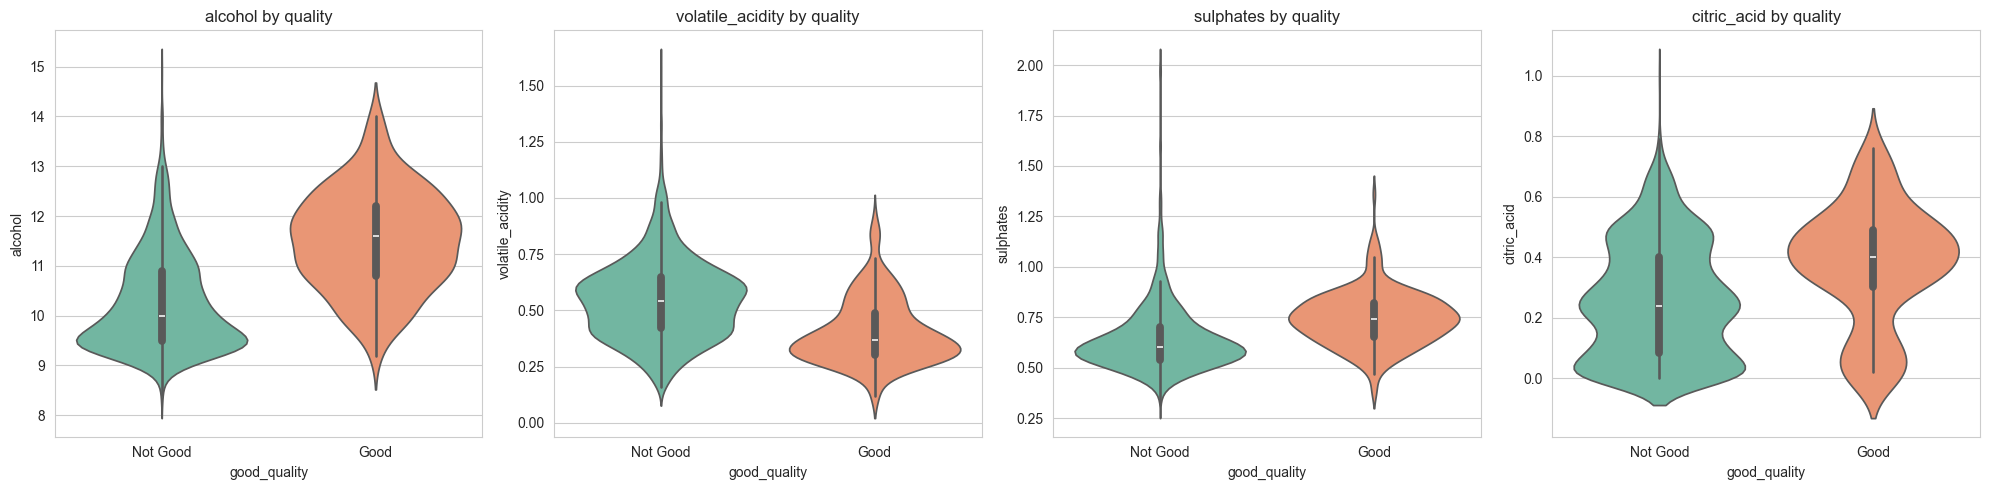

In [11]:
key = ["alcohol", "volatile_acidity", "sulphates", "citric_acid"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(key):
    sns.violinplot(x="good_quality", y=col, data=df, palette="Set2", ax=axes[i])
    axes[i].set_xticklabels(["Not Good", "Good"])
    axes[i].set_title(f"{col} by quality")
plt.tight_layout(); plt.show()

## 7. Correlation Analysis

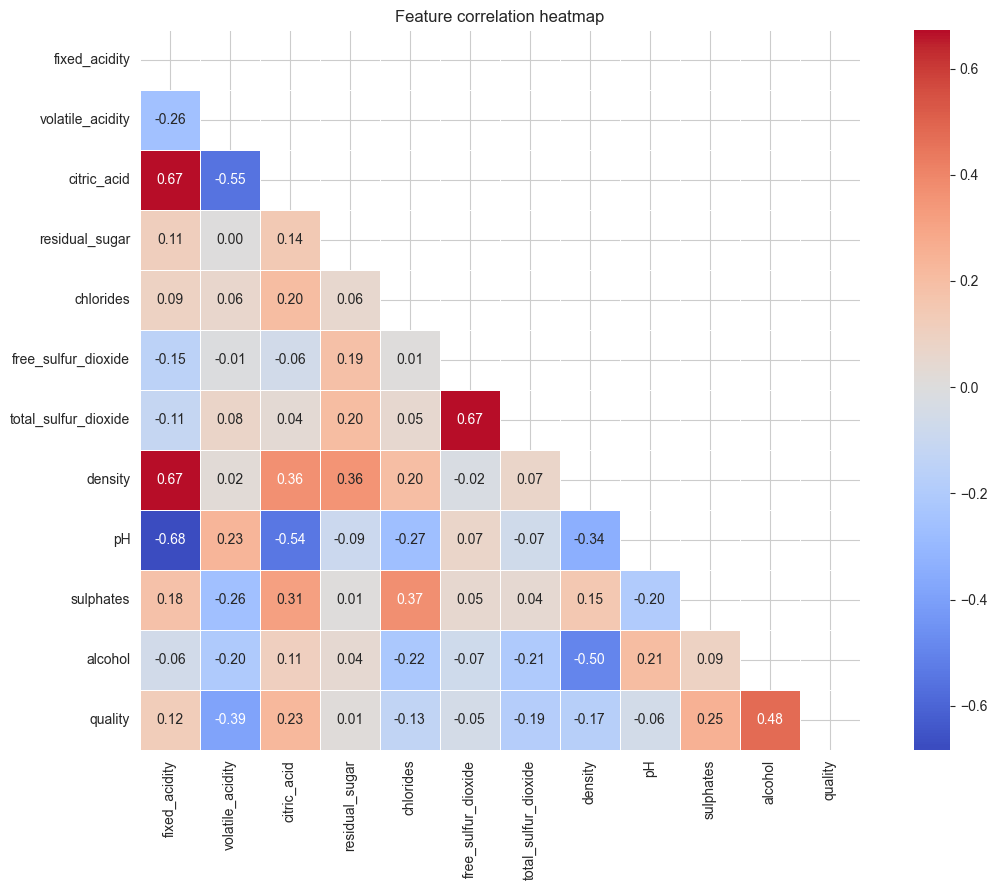

In [12]:
plt.figure(figsize=(12, 9))
corr = df.drop(columns=["good_quality"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Feature correlation heatmap")
plt.tight_layout(); plt.show()

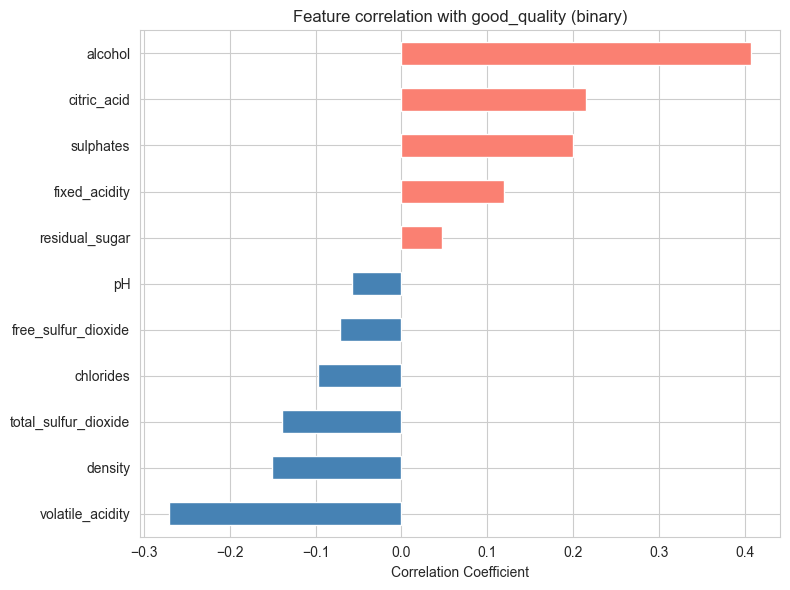

alcohol                 0.407
citric_acid             0.215
sulphates               0.199
fixed_acidity           0.120
residual_sugar          0.048
pH                     -0.057
free_sulfur_dioxide    -0.072
chlorides              -0.097
total_sulfur_dioxide   -0.140
density                -0.150
volatile_acidity       -0.271
Name: good_quality, dtype: float64


In [13]:
target_corr = df.corr()["good_quality"].drop(["good_quality", "quality"]).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
target_corr.plot(kind="barh",
                 color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Feature correlation with good_quality (binary)")
plt.xlabel("Correlation Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print(target_corr.round(3))

## 8. Acidity & Alcohol Deep-Dive

Alcohol and volatile acidity are the strongest linear predictors. Below we look at their joint structure.

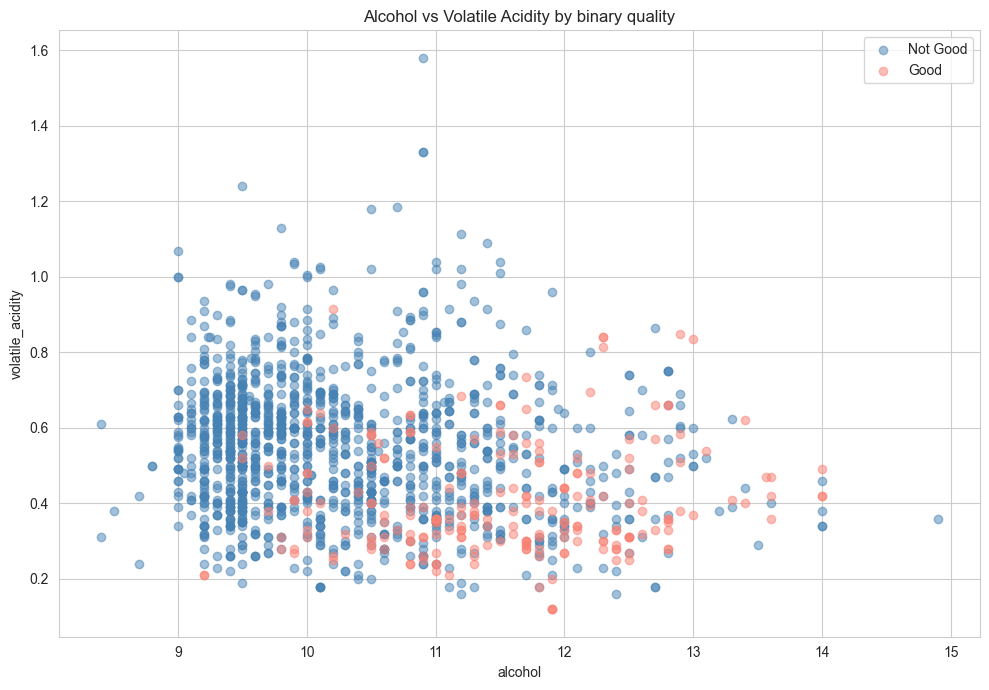

In [14]:
plt.figure(figsize=(10, 7))
for q, color, label in [(0, "steelblue", "Not Good"), (1, "salmon", "Good")]:
    s = df[df["good_quality"] == q]
    plt.scatter(s["alcohol"], s["volatile_acidity"], c=color, alpha=0.5, label=label)
plt.xlabel("alcohol"); plt.ylabel("volatile_acidity")
plt.title("Alcohol vs Volatile Acidity by binary quality")
plt.legend(); plt.tight_layout(); plt.show()

In [15]:
print("Good-wine rate by alcohol bucket:")
for label, lo, hi in [("low (<9.5)", 0, 9.5), ("medium (9.5-11)", 9.5, 11), ("high (>=11)", 11, 20)]:
    sub = df[(df["alcohol"] >= lo) & (df["alcohol"] < hi)]
    if len(sub):
        rate = sub["good_quality"].mean() * 100
        print(f"  {label:18s}: {rate:.1f}%  (n={len(sub)})")

Good-wine rate by alcohol bucket:
  low (<9.5)        : 0.7%  (n=297)
  medium (9.5-11)   : 7.3%  (n=835)
  high (>=11)       : 33.0%  (n=467)


## 9. Pair Plot — Top Features

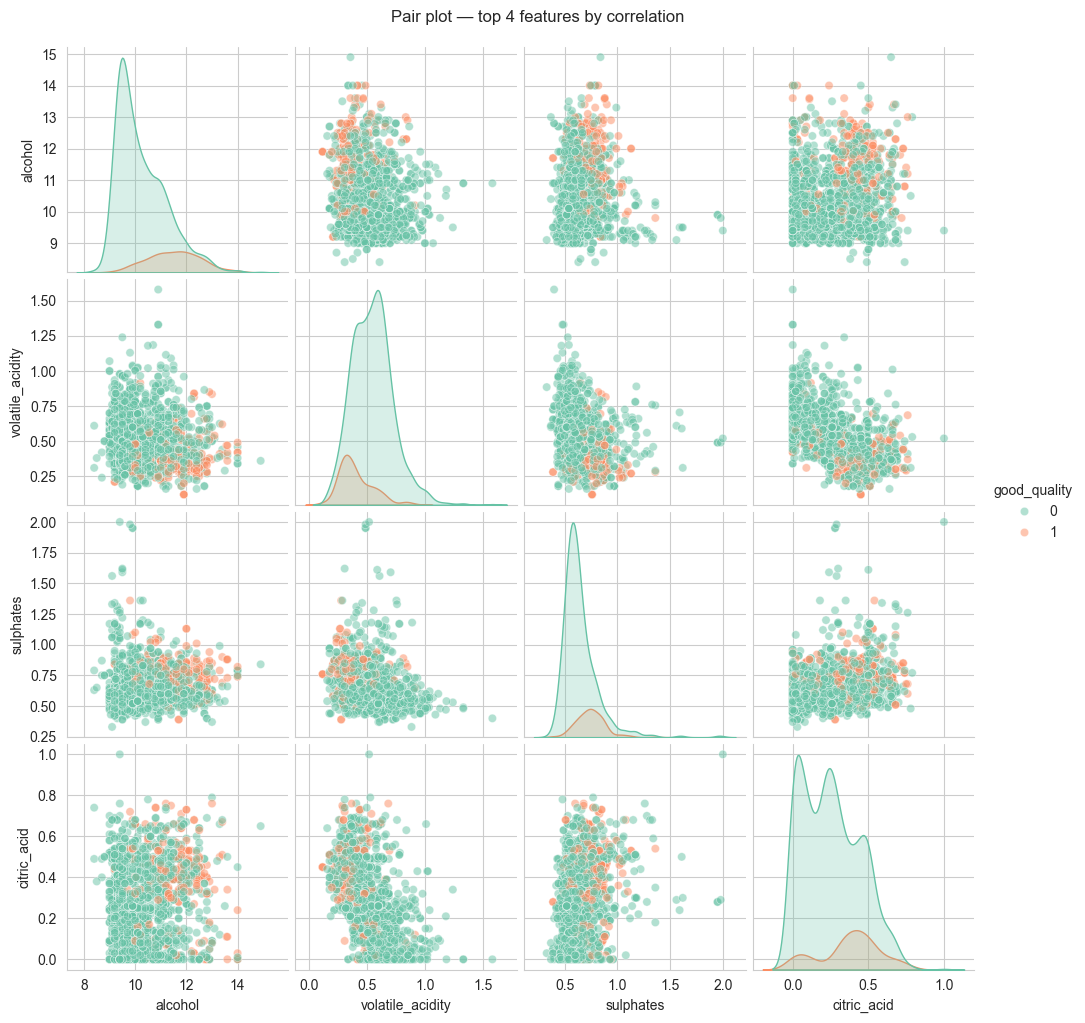

In [16]:
top = ["alcohol", "volatile_acidity", "sulphates", "citric_acid", "good_quality"]
sns.pairplot(df[top], hue="good_quality", palette="Set2", diag_kind="kde",
             plot_kws={"alpha": 0.5})
plt.suptitle("Pair plot — top 4 features by correlation", y=1.02)
plt.show()

## 10. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **Class imbalance**: only ~13.6% of wines score ≥7 — the binary target is heavily skewed |
| 2 | **Alcohol (r ≈ 0.48)** is the single strongest linear predictor — good wines average ~11.5% ABV vs ~10.2% for not-good |
| 3 | **Volatile acidity (r ≈ −0.39)** is the strongest negative predictor — vinegar character ruins quality |
| 4 | **Sulphates (r ≈ 0.25)** and **citric acid (r ≈ 0.22)** also correlate positively with good wines |
| 5 | **Density and fixed acidity** are highly intercorrelated — expect multicollinearity |
| 6 | **No missing values**, but several features (residual sugar, chlorides, sulphates) have heavy right-tails — outliers worth noting |
| 7 | **Quality scores cluster at 5–6** — the dataset is dominated by mid-quality wines, and a `>=7` cutoff yields the cleanest "good vs not-good" split |